In [2]:
import os

for root, dirs, files in os.walk('/kaggle/input'):
    print(root)
    print("Folders:", len(dirs))
    print("Files:", len(files))
    print("-"*50)

/kaggle/input
Folders: 1
Files: 0
--------------------------------------------------
/kaggle/input/datasets
Folders: 1
Files: 0
--------------------------------------------------
/kaggle/input/datasets/fuankarion
Folders: 1
Files: 0
--------------------------------------------------
/kaggle/input/datasets/fuankarion/hmdb51-9class
Folders: 9
Files: 2
--------------------------------------------------
/kaggle/input/datasets/fuankarion/hmdb51-9class/catch
Folders: 0
Files: 91
--------------------------------------------------
/kaggle/input/datasets/fuankarion/hmdb51-9class/climb_stairs
Folders: 0
Files: 112
--------------------------------------------------
/kaggle/input/datasets/fuankarion/hmdb51-9class/clap
Folders: 0
Files: 121
--------------------------------------------------
/kaggle/input/datasets/fuankarion/hmdb51-9class/dive
Folders: 0
Files: 127
--------------------------------------------------
/kaggle/input/datasets/fuankarion/hmdb51-9class/climb
Folders: 0
Files: 108
---------

In [11]:
import pandas as pd

train_df = pd.read_csv('/kaggle/input/datasets/fuankarion/hmdb51-9class/train_data.csv')
test_df = pd.read_csv('/kaggle/input/datasets/fuankarion/hmdb51-9class/val_data.csv')

print(train_df.head())
print(train_df.columns)
print(train_df.shape)

print(test_df.head())
print(test_df.shape)

  climb/Pole_climbing_World_Championships_climb_f_nm_np1_ba_med_1   76
0  climb/DM_Sportklettern_2006_Video_Qualifikatio...               124
1  climb/Axel_beim_Klettern_an_der_Unisportwand_c...                91
2  climb/Lead_Climbing_Roof_at_Stoneworks_climb_f...                90
3  climb/KletterWM_2005_Bouldern_Finale_Damen__Ve...               246
4  climb/India_Monkey_King_scales_new_heights_cli...               114
Index(['climb/Pole_climbing_World_Championships_climb_f_nm_np1_ba_med_1', '76'], dtype='object')
(773, 2)
  climb/DM_Sportklettern_2006_Video_Qualifikation__Julia_Winter_climb_f_cm_np1_ba_med_0  \
0  climb/Amazing_Wall_Climber_Must_be_Seen_to_Be_...                                      
1  climb/rope_climb_Olivia_Age_4_climb_f_cm_np1_r...                                      
2  climb/Dan_Osman__Speed_rock_climbing_climb_f_c...                                      
3  climb/Bristol_UCR_roof_climb_climb_f_cm_np1_ba...                                      
4  climb/Rock

In [12]:
import os
import cv2
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm import tqdm

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

import tensorflow as tf

from tensorflow.keras.utils import to_categorical
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import *
from tensorflow.keras.models import Sequential

In [13]:
DATASET_PATH = "/kaggle/input/datasets/fuankarion/hmdb51-9class"

IMG_SIZE = 96
SEQUENCE_LENGTH = 10

EPOCHS = 15
BATCH_SIZE = 8

In [14]:
classes = []

for item in os.listdir(DATASET_PATH):
    path = os.path.join(DATASET_PATH, item)

    if os.path.isdir(path):
        classes.append(item)

classes = sorted(classes)

print(classes)
print("Number of Classes:", len(classes))

['brush_hair', 'cartwheel', 'catch', 'chew', 'clap', 'climb', 'climb_stairs', 'dive', 'draw_sword']
Number of Classes: 9


In [15]:
def extract_frames(video_path):

    frames = []

    cap = cv2.VideoCapture(video_path)

    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    skip = max(total_frames // SEQUENCE_LENGTH, 1)

    for i in range(SEQUENCE_LENGTH):

        cap.set(cv2.CAP_PROP_POS_FRAMES, i * skip)

        success, frame = cap.read()

        if not success:
            break

        frame = cv2.resize(frame, (IMG_SIZE, IMG_SIZE))

        frame = frame.astype("float32") / 255.0

        frames.append(frame)

    cap.release()

    while len(frames) < SEQUENCE_LENGTH:
        frames.append(
            np.zeros((IMG_SIZE, IMG_SIZE, 3))
        )

    return np.array(frames)

In [16]:
X = []
y = []

for label in classes:

    class_path = os.path.join(DATASET_PATH, label)

    videos = os.listdir(class_path)

    print("Loading:", label)

    for video in tqdm(videos):

        video_path = os.path.join(class_path, video)

        try:

            frames = extract_frames(video_path)

            X.append(frames)

            y.append(label)

        except:
            pass

Loading: brush_hair


100%|██████████| 107/107 [00:26<00:00,  4.03it/s]


Loading: cartwheel


100%|██████████| 103/103 [00:11<00:00,  9.28it/s]


Loading: catch


...

100%|██████████| 112/112 [00:13<00:00,  8.42it/s]


Loading: dive


100%|██████████| 127/127 [00:13<00:00,  9.39it/s]


Loading: draw_sword


100%|██████████| 103/103 [00:09<00:00, 10.66it/s]


In [17]:
X = np.array(X, dtype=np.float32)

print(X.shape)

(978, 10, 96, 96, 3)


In [18]:
encoder = LabelEncoder()

y_encoded = encoder.fit_transform(y)

y_encoded = to_categorical(y_encoded)

print(y_encoded.shape)

(978, 9)


In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

print(X_train.shape)
print(X_test.shape)

(782, 10, 96, 96, 3)
(196, 10, 96, 96, 3)


In [20]:
cnn = MobileNetV2(
    weights="imagenet",
    include_top=False,
    pooling="avg",
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

cnn.trainable = False

I0000 00:00:1780037453.601516      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1780037453.607067      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [21]:
model = Sequential()

model.add(
    TimeDistributed(
        cnn,
        input_shape=(
            SEQUENCE_LENGTH,
            IMG_SIZE,
            IMG_SIZE,
            3
        )
    )
)

model.add(
    LSTM(
        128,
        return_sequences=True
    )
)

model.add(
    Dropout(0.5)
)

model.add(
    LSTM(64)
)

model.add(
    Dense(
        128,
        activation="relu"
    )
)

model.add(
    Dropout(0.3)
)

model.add(
    Dense(
        len(classes),
        activation="softmax"
    )
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/wrapper.py:27: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ time_distributed                │ (None, 10, 1280)       │     2,257,984 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 10, 128)        │       721,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 10, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 9)              │         1,161 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,038,281 (11.59 MB)

 Trainable params: 780,297 (2.98 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [22]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [23]:
history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE
)

Epoch 1/15


I0000 00:00:1780037519.286436   13859 cuda_dnn.cc:529] Loaded cuDNN version 91002


79/79 ━━━━━━━━━━━━━━━━━━━━ 57s 231ms/step - accuracy: 0.4336 - loss: 1.6583 - val_accuracy: 0.6688 - val_loss: 1.1087
Epoch 2/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 6s 70ms/step - accuracy: 0.7024 - loss: 0.8980 - val_accuracy: 0.7261 - val_loss: 0.8209
Epoch 3/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 6s 69ms/step - accuracy: 0.7888 - loss: 0.6907 - val_accuracy: 0.7452 - val_loss: 0.7336
Epoch 4/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 6s 69ms/step - accuracy: 0.8624 - loss: 0.4365 - val_accuracy: 0.8089 - val_loss: 0.6321
Epoch 5/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 6s 70ms/step - accuracy: 0.9056 - loss: 0.3196 - val_accuracy: 0.7707 - val_loss: 0.8336
Epoch 6/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 5s 69ms/step - accuracy: 0.9056 - loss: 0.3094 - val_accuracy: 0.7962 - val_loss: 0.6693
Epoch 7/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 5s 69ms/step - accuracy: 0.9344 - loss: 0.1922 - val_accuracy: 0.7452 - val_loss: 0.9817
Epoch 8/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 5s 69ms/step - accuracy: 0.9408 - loss: 0.2000 - val_accuracy: 0.8280 - val_loss: 

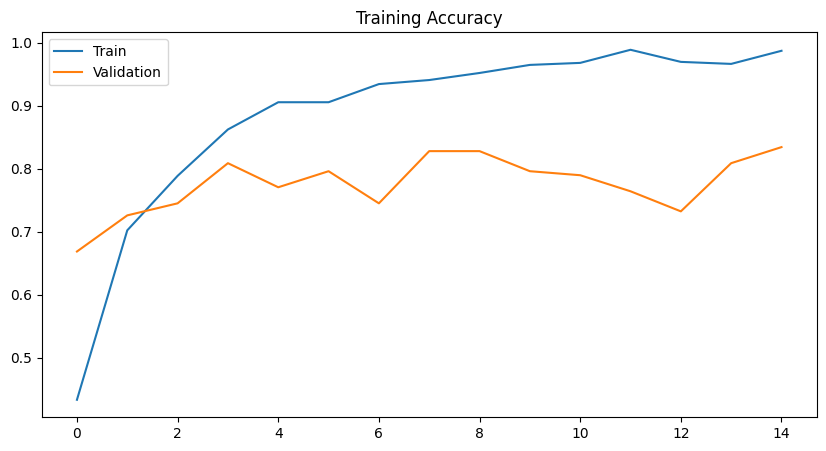

In [24]:
plt.figure(figsize=(10,5))

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Training Accuracy")
plt.legend(['Train','Validation'])

plt.show()

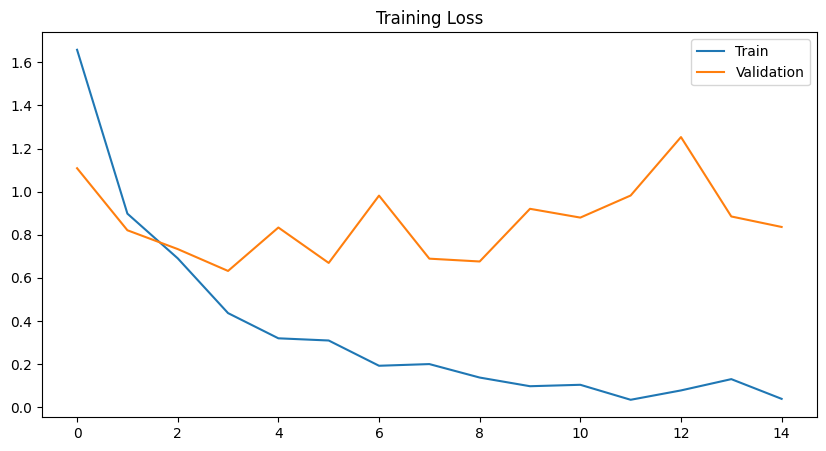

In [25]:
plt.figure(figsize=(10,5))

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("Training Loss")
plt.legend(['Train','Validation'])

plt.show()

In [26]:
loss, accuracy = model.evaluate(
    X_test,
    y_test
)

print("Test Accuracy:", accuracy)

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 147ms/step - accuracy: 0.8469 - loss: 0.7854
Test Accuracy: 0.8469387888908386


In [27]:
pred = model.predict(X_test)

pred_classes = np.argmax(pred, axis=1)

true_classes = np.argmax(y_test, axis=1)

7/7 ━━━━━━━━━━━━━━━━━━━━ 21s 2s/step 


In [28]:
print(
    classification_report(
        true_classes,
        pred_classes,
        target_names=classes
    )
)

              precision    recall  f1-score   support

  brush_hair       0.71      0.95      0.82        21
   cartwheel       0.79      0.90      0.84        21
       catch       1.00      0.83      0.91        18
        chew       0.95      0.86      0.90        21
        clap       0.78      0.75      0.77        24
       climb       0.77      0.91      0.83        22
climb_stairs       1.00      0.77      0.87        22
        dive       0.88      0.81      0.84        26
  draw_sword       0.90      0.86      0.88        21

    accuracy                           0.85       196
   macro avg       0.86      0.85      0.85       196
weighted avg       0.86      0.85      0.85       196



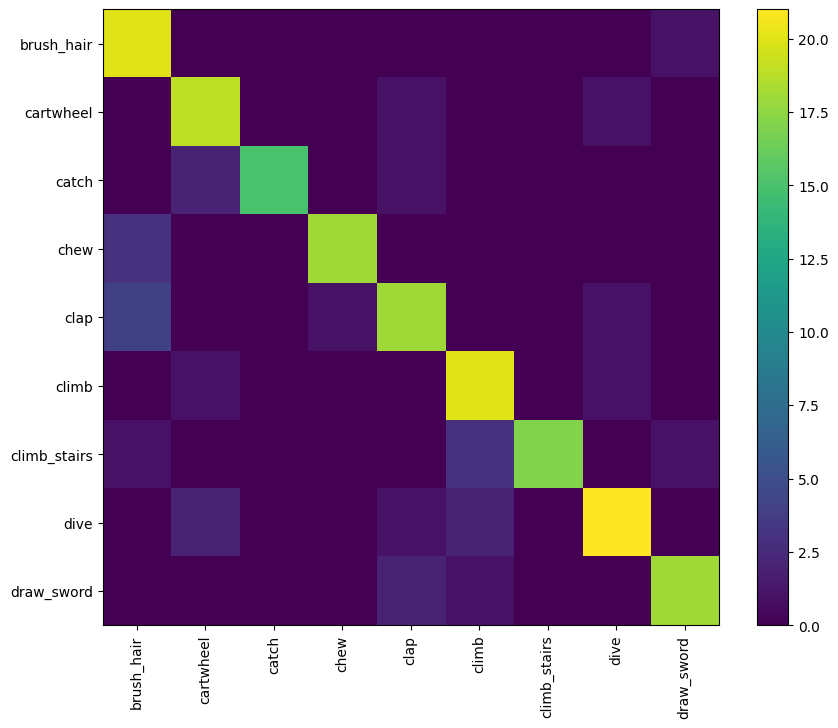

In [29]:
cm = confusion_matrix(
    true_classes,
    pred_classes
)

plt.figure(figsize=(10,8))

plt.imshow(cm)

plt.colorbar()

plt.xticks(
    range(len(classes)),
    classes,
    rotation=90
)

plt.yticks(
    range(len(classes)),
    classes
)

plt.show()